# 🤖 Predict Titanic Survival — My First Classification Model

## Logistic Regression with Scikit-Learn

### 📌 Introduction

This notebook is Task 3 of the Neurofive ML Track and marks my first step into building an actual Machine Learning model.

In the previous tasks, I explored and cleaned the Titanic dataset and used visualizations to understand patterns within the data. Now, I will use that knowledge to build a classification model that predicts whether a passenger survived the Titanic disaster.

For this task, I will use **Logistic Regression**, a supervised machine learning algorithm commonly used for binary classification problems.

The target variable will be `Survived`, where:
- `0` = Did not survive
- `1` = Survived

I will prepare the data, encode categorical features, split it into training and testing sets, train the model, and evaluate its performance using accuracy and a confusion matrix.

---

## 📋 Table of Contents

1. [Import Libraries](#1-import-libraries)
2. [Load Dataset](#2-load-dataset)
3. [Initial Dataset Inspection](#3-initial-dataset-inspection)
4. [Handle Missing Values](#4-handle-missing-values)
5. [Select Features and Target](#5-select-features-and-target)
6. [Encode Categorical Features](#6-encode-categorical-features)
7. [Split Data into Training and Testing Sets](#7-split-data-into-training-and-testing-sets)
8. [Train Logistic Regression Model](#8-train-logistic-regression-model)
9. [Make Predictions](#9-make-predictions)
10. [Evaluate Model Accuracy](#10-evaluate-model-accuracy)
11. [Confusion Matrix](#11-confusion-matrix)
12. [Explain Confusion Matrix](#12-explain-confusion-matrix)
13. [Analyze Model Results](#13-analyze-model-results)
14. [Conclusion](#14-conclusion)

In [1]:
# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# 2. Load Dataset

# Load the Titanic dataset
df = pd.read_csv("train.csv")

print("Titanic dataset loaded successfully!")

Titanic dataset loaded successfully!


In [3]:
# 3. Initial Dataset Inspection

# Display the first five rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# 3. Initial Dataset Inspection - Dataset Information

# Display dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# 4. Handle Missing Values

# Fill missing Age values with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with the mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin because most of its values are missing
df = df.drop(columns=["Cabin"])

print("Missing values handled successfully!")

Missing values handled successfully!


In [6]:
# 4. Handle Missing Values - Verify Cleaning

# Check for remaining missing values
print("Remaining missing values:")
print(df.isnull().sum())

Remaining missing values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [7]:
# 5. Select Features and Target

# Select the features that will be used for prediction
X = df[[
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]]

# Select the target variable
y = df["Survived"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("Survived")

Features:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

Target:
Survived


In [8]:
# 6. Encode Categorical Features

# Convert categorical columns into numerical dummy variables
X_encoded = pd.get_dummies(
    X,
    columns=["Sex", "Embarked"],
    drop_first=True
)

# Display the encoded features
X_encoded.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [9]:
# 6. Encode Categorical Features - Check Data Types

# Display the data types after encoding
X_encoded.dtypes

,0
Pclass,int64
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Sex_male,bool
Embarked_Q,bool
Embarked_S,bool


In [10]:
# 6. Encode Categorical Features - Convert Boolean Values

# Convert Boolean values into integers
X_encoded = X_encoded.astype(int)

print("Categorical features encoded successfully!")

Categorical features encoded successfully!


In [11]:
# 7. Split Data into Training and Testing Sets

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 712
Testing samples: 179


In [12]:
# 7. Split Data into Training and Testing Sets - Check Shapes

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (712, 8)
X_test shape: (179, 8)
y_train shape: (712,)
y_test shape: (179,)


In [13]:
# 8. Train Logistic Regression Model

# Create the Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model using the training data
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [14]:
# 9. Make Predictions

# Use the trained model to predict survival on the test data
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!

First 10 predictions:
[0 0 0 0 1 0 1 0 0 0]


In [15]:
# 9. Make Predictions - Compare Actual and Predicted Values

# Create a comparison DataFrame
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,1,0
3,0,0
4,1,1
5,1,0
6,1,1
7,0,0
8,0,0
9,0,0


In [16]:
# 10. Evaluate Model Accuracy

# Calculate the model accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 80.45%


In [17]:
# 11. Confusion Matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[98 12]
 [23 46]]


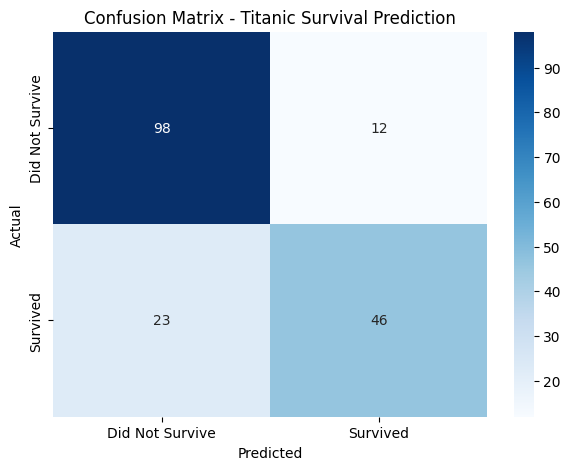

In [18]:
# 11. Confusion Matrix - Visualization

# Create a heatmap for the confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.title("Confusion Matrix - Titanic Survival Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# 12. Explain Confusion Matrix

A confusion matrix shows how the model's predictions compare with the actual outcomes.

The matrix contains four possible results:

- **True Negative (TN):** The passenger did not survive, and the model correctly predicted that they did not survive.
- **False Positive (FP):** The passenger did not survive, but the model incorrectly predicted survival.
- **False Negative (FN):** The passenger survived, but the model incorrectly predicted that they did not survive.
- **True Positive (TP):** The passenger survived, and the model correctly predicted survival.

The diagonal values represent the predictions that the model got correct, while the values outside the diagonal represent incorrect predictions.

Therefore, the confusion matrix gives more detail than accuracy alone because it shows **what types of mistakes the model is making**.

In [19]:
# 12. Explain Confusion Matrix - Extract Prediction Counts

# Extract the four confusion matrix values
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 98
False Positives: 12
False Negatives: 23
True Positives : 46


# 13. Analyze Model Results

The Logistic Regression model achieved an accuracy of approximately **80%** on the test dataset.

This means that the model correctly predicted the survival outcome for roughly 8 out of every 10 passengers in the test set.

The confusion matrix shows that the model makes both correct and incorrect predictions. Looking at the True Positives and True Negatives helps us understand how many passengers were classified correctly, while False Positives and False Negatives show where the model made mistakes.

Although an accuracy of around 80% is a reasonable result for a first classification model, it does not mean the model is perfect. Some passenger outcomes are difficult to predict based only on the features provided.

This first model provides a useful baseline that could be improved later through better feature engineering, preprocessing, and other classification algorithms.

In [20]:
# 13. Analyze Model Results - Final Model Summary

print("===== MODEL SUMMARY =====")
print(f"Model: Logistic Regression")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Accuracy: {accuracy:.2%}")

print("\nConfusion Matrix:")
print(cm)

===== MODEL SUMMARY =====
Model: Logistic Regression
Training samples: 712
Testing samples: 179
Accuracy: 80.45%

Confusion Matrix:
[[98 12]
 [23 46]]


# 14. Conclusion

This task marked my first step from Exploratory Data Analysis into Machine Learning.

Using the cleaned Titanic dataset, I prepared the features, encoded categorical variables, and divided the data into training and testing sets using `train_test_split()`.

I then trained a **Logistic Regression classification model** to predict whether a passenger survived the Titanic disaster.

The model was evaluated using `accuracy_score()` and a confusion matrix. The accuracy provided an overall measure of correct predictions, while the confusion matrix helped me understand the specific types of errors made by the model.

The model achieved approximately **80% accuracy**, providing a useful baseline for this classification problem.

The biggest lesson from this task is that building a machine learning model is not just about calling `.fit()`. The work done before modeling, including cleaning, selecting, and encoding the data, directly affects what the model can learn.

This is my first classification model, and it provides the foundation for exploring more machine learning algorithms and improving model performance in future tasks.